In [ ]:
import pandas as pd
df = pd.read_excel('Online Retail.xlsx')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Online Retail.xlsx'

In [ ]:
import zipfile

with zipfile.ZipFile('/content/online+retail.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
import os
os.listdir('/content/')


['.config', 'Online Retail.xlsx', 'online+retail.zip', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_excel('/content/Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df[df['Quantity']<0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
df[df['UnitPrice'] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [ ]:
# Step 1: Remove rows with missing CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# Step 2: Remove cancelled orders (negative quantity)
df_clean = df_clean[df_clean['Quantity'] > 0]

# Step 3: Remove rows with zero or negative price
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Check how much data we have left
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))

Original rows: 541909
Cleaned rows: 397884


In [ ]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
import datetime as dt

reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


In [ ]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

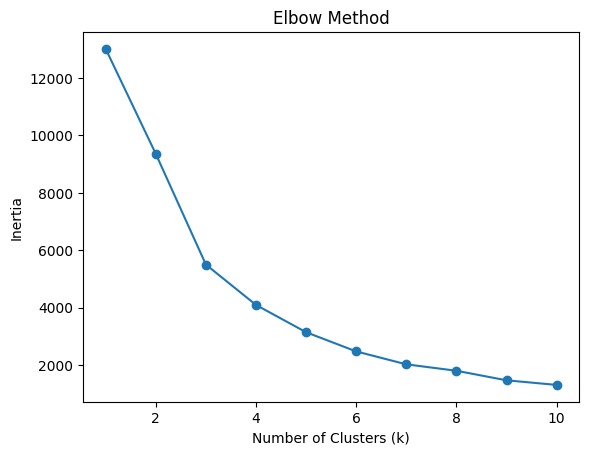

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head(10)

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1
12352.0,36,8,2506.04,0
12353.0,204,1,89.00,1
12354.0,232,1,1079.40,1
12355.0,214,1,459.40,1


In [ ]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'})

cluster_summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,43.702685,3.682711,1359.049284,3054
1,248.075914,1.552015,480.617480,1067
2,7.384615,82.538462,127338.313846,13
3,15.500000,22.333333,12709.090490,204


In [ ]:
segment_map = {
    2: 'VIP/Champions',
    3: 'Loyal High-Value',
    0: 'Regular/Promising',
    1: 'At Risk/Lost'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)
rfm.head(10)

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal High-Value
12347.0,2,7,4310.00,0,Regular/Promising
12348.0,75,4,1797.24,0,Regular/Promising
12349.0,19,1,1757.55,0,Regular/Promising
12350.0,310,1,334.40,1,At Risk/Lost
12352.0,36,8,2506.04,0,Regular/Promising
12353.0,204,1,89.00,1,At Risk/Lost
12354.0,232,1,1079.40,1,At Risk/Lost
12355.0,214,1,459.40,1,At Risk/Lost


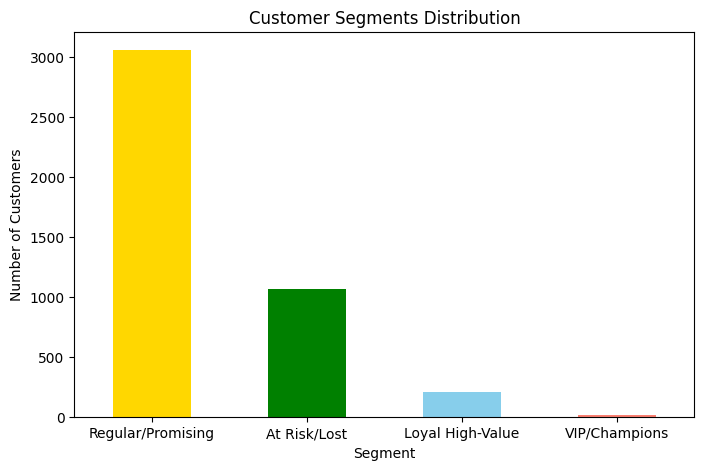

In [ ]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar', color=['gold', 'green', 'skyblue', 'salmon'])
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

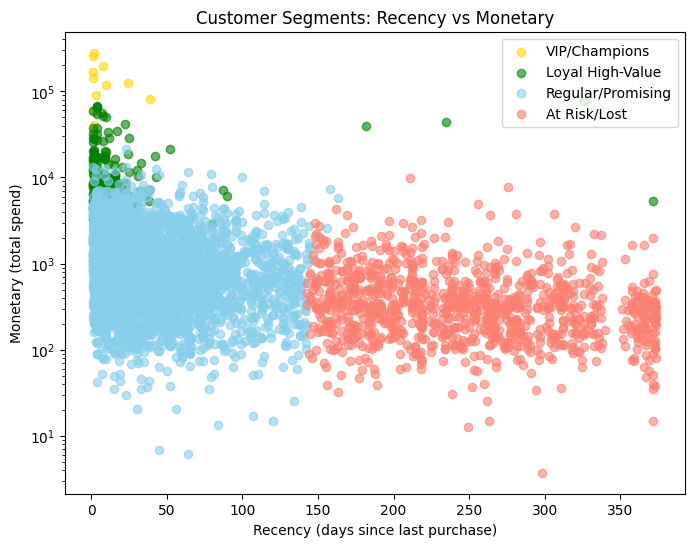

In [ ]:
plt.figure(figsize=(8,6))

colors = {'VIP/Champions': 'gold', 'Loyal High-Value': 'green',
          'Regular/Promising': 'skyblue', 'At Risk/Lost': 'salmon'}

for segment, color in colors.items():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Recency'], subset['Monetary'], label=segment, color=color, alpha=0.6)

plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend)')
plt.title('Customer Segments: Recency vs Monetary')
plt.legend()
plt.yscale('log')  # because VIPs have huge values that would squish everything else
plt.show()